<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 2. Import the dataset

In [2]:
df=pd.read_csv('50_Startups.csv')

In [3]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [4]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [5]:
x=df.iloc[::,:4:]
y=df.iloc[::,4::]
x

,R&D Spend,Administration,Marketing Spend,State
0,165349.20,136897.80,471784.10,New York
1,162597.70,151377.59,443898.53,California
2,153441.51,101145.55,407934.54,Florida
3,144372.41,118671.85,383199.62,New York
4,142107.34,91391.77,366168.42,Florida
5,131876.90,99814.71,362861.36,New York
6,134615.46,147198.87,127716.82,California
7,130298.13,145530.06,323876.68,Florida
8,120542.52,148718.95,311613.29,New York
9,123334.88,108679.17,304981.62,California


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [6]:
x1=pd.get_dummies(x,columns=['State'],drop_first=True)

In [7]:
x1

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [11]:
# Already Performed using | drop_first =True

## Step 7 Splitting dataset in to Train and Test

In [8]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x1,y,train_size=0.8,random_state=42)

## Step 8  Import LinearRegression model from linear_model family 

In [15]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

## Step 9  Fit the data

In [16]:
print(model.fit(x_train,y_train))

LinearRegression()


## Step 10  Predict the data

In [17]:
y_pred=model.predict(x_test)
y_pred

array([[126362.87908255],
       [ 84608.45383634],
       [ 99677.49425147],
       [ 46357.46068582],
       [128750.48288504],
       [ 50912.4174188 ],
       [109741.35032702],
       [100643.24281647],
       [ 97599.27574594],
       [113097.42524432]])

## Step 11  Display Result

In [18]:
# y_test and y_predict

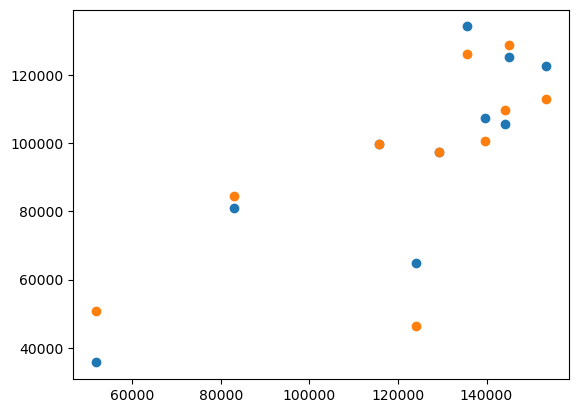

In [19]:
plt.scatter(x_test['Administration'],y_test)
plt.scatter(x_test['Administration'],y_pred)

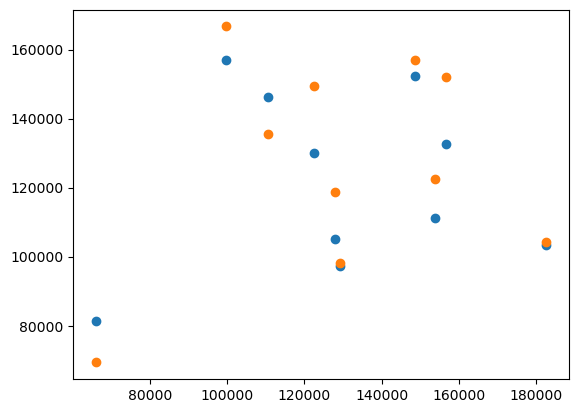

## RSS

In [20]:
np.sum((y_test.values-y_pred)**2)

820103630.4430102

In [21]:
len(y_test)

10

10

In [22]:
from sklearn.metrics import mean_squared_error

In [23]:
mean_squared_error(y_test.values,y_pred)*len(y_pred)

820103630.4430102

In [24]:
len(y_pred)

10

## R Square

In [27]:
from sklearn.metrics import r2_score

In [28]:
r2_score(y_test,y_pred)

0.8987266414328637